<a href="https://colab.research.google.com/github/JinwaOssData/OssData01/blob/main/std001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026-2-중간-오픈소스기반데이터분석

공공데이터포털(https://data.go.kr)에서 "한국농수산식품유통공사_일별 도,소매 가격정보 조회

https://www.data.go.kr/data/15156057/openapi.do

1-2 API를 호출하는 파이썬 코드를 작성하고, 2015년부터 2024년까지 서울 가락도매시장의 배추(품종: 봄/여름(고랭지)/가을/월동) 가격 데이터를 수집하는 프로그램을 작성하시오. 파이썬 코드와 API 호출 성공을 확인할 수 있는 실행 결과를 캡처하여 첨부하시오. (7점)

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '200',
    'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101',
    'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02',
    'cond[ctgry_cd::EQ]': '200',
    'cond[item_cd::EQ]': '211',
    'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101',
    'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 호출 성공/실패 출력
if response.status_code == 200:
    print('API 호출 성공')
else:
    print('API 호출 실패')


API 호출 성공


문 2-1. 수집한 JSON 형태의 데이터를 pandas DataFrame으로 변환하고, 데이터의 기본 정보를 출력하는 파이썬 코드와 실행 결과를 첨부하시오. (4점)

In [ ]:
import requests
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '200', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()['response']['body']['items']['item']

df = pd.DataFrame(data)
print(df.info())


문 2-2. 연도별, 계절별 분석을 위해 조사일자(exmn_ymd) 컬럼을 활용하여 연도(year)와 계절(season) 컬럼을 추가하는 전처리 코드를 작성하고, 변환 결과를 확인할 수 있는 출력 결과를 첨부하시오. (4점)
※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)

In [ ]:
import requests
import json
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '200', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 데이터 파싱, pandas DataFrame 으로 변환
data = response.json()['response']['body']['items']['item']
df = pd.DataFrame(data)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return 'NaN'
    elif month in ('3','4','5'): return '봄'
    elif month in ('6','7','8'): return '여름'
    elif month in ('9','10','11'): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## pd 출력
df

문 3-1. 연도별 배추 평균 가격(exmn_dd_prc) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오.

(예: "연도별 배추 평균 가격 변화 - 1234")
시각화 코드와 생성된 그래프를 첨부하시오. (4점)

어떻게 해도 한글이 깨짐

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 한글 깨짐 방지 및 스타일 설정
font_url = "https://github.com"
font_path = "./NanumBarunGothic.ttf"

if not os.path.exists(font_path):
    import urllib.request
    urllib.request.urlretrieve(font_url, font_path)

plt.rcParams['font.family'] = 'NanumBarunGothic'
#font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

HAKBUN_R4 = '1480'

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 데이터 파싱, pandas DataFrame 으로 변환
data = response.json()['response']['body']['items']['item']
df = pd.DataFrame(data)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return 'NaN'
    elif month in ('3','4','5'): return '봄'
    elif month in ('6','7','8'): return '여름'
    elif month in ('9','10','11'): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## 가격을 수치형 데이터로 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

## 품목이 '배추'인 데이터만 필터링 후 연도별 평균 가격 산출
df_cabbage = df[df['item_nm'] == '배추']
yearly_avg = df_cabbage.groupby('year')['exmn_dd_prc'].mean().reset_index()

## 선 그래프 시각화 설정
plt.figure(figsize=(9, 5))
plt.plot(yearly_avg['year'], yearly_avg['exmn_dd_prc'],
         marker='o', color='#2ca02c', linestyle='-', linewidth=2, markersize=8, label='Average Price (KRW)')

## 그래프 요소 지정 (학번 포함 제목 설정)
plt.title(f"연도별 배추 평균 가격 변화 - {HAKBUN_R4}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("연도 (Year)", fontsize=11, labelpad=10)
plt.ylabel("평균 가격 (원)", fontsize=11, labelpad=10)
plt.xticks(yearly_avg['year']) # X축에 연도가 고르게 표시되도록 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

## 데이터 라벨링 (각 점 위에 가격 수치 표시)
for i, txt in enumerate(yearly_avg['exmn_dd_prc']):
    plt.annotate(f"{int(txt):,}원", (yearly_avg['year'].iloc[i], yearly_avg['exmn_dd_prc'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

## 지정된 파일명 양식으로 이미지 저장
filename = f"연도별_배추_평균_가격_변화_{HAKBUN_R4}.png"
plt.savefig(filename, dpi=300)
plt.show()

## 텍스트 확인용 데이터 출력
print(yearly_avg)

문 3-1. 연도별 배추 평균 가격(exmn_dd_prc) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오.

(예: "연도별 배추 평균 가격 변화 - 1234") 시각화 코드와 생성된 그래프를 첨부하시오. (4점)

/tmp/ipykernel_1927/726482473.py:93: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1927/726482473.py:97: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  plt.savefig(filename, dpi=300)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


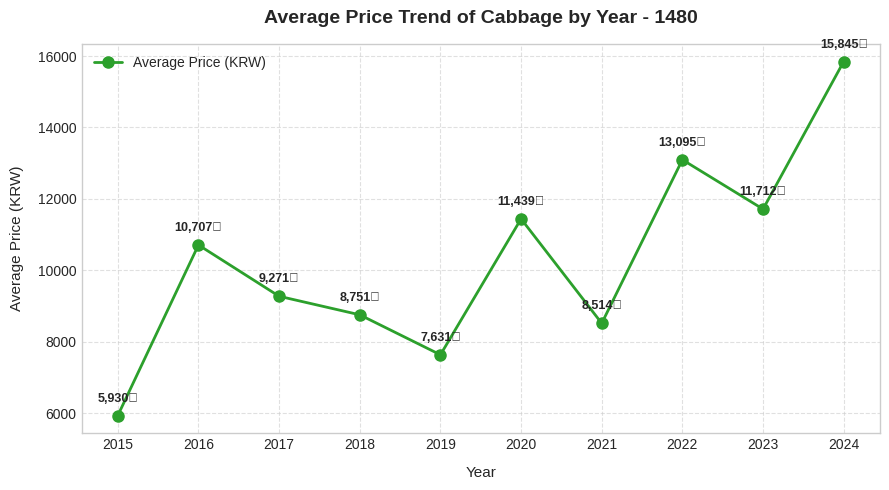

   year   exmn_dd_prc
0  2015   5930.147059
1  2016  10707.581227
2  2017   9271.317829
3  2018   8751.893939
4  2019   7631.782946
5  2020  11439.007092
6  2021   8514.062500
7  2022  13095.312500
8  2023  11712.062257
9  2024  15845.530303


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

HAKBUN_R4 = '1480'

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

## 데이터 수집, vrty_cd(품종코드) : (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
response1 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '01'
})
response2 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '02'
})
response3 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '03'
})
response4 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '06'
})

## 데이터 파싱, pandas DataFrame 으로 변환
df1 = pd.DataFrame(response1.json()['response']['body']['items']['item'])
df2 = pd.DataFrame(response2.json()['response']['body']['items']['item'])
df3 = pd.DataFrame(response3.json()['response']['body']['items']['item'])
df4 = pd.DataFrame(response4.json()['response']['body']['items']['item'])
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return 'NaN'
    elif month in ('3','4','5'): return '봄'
    elif month in ('6','7','8'): return '여름'
    elif month in ('9','10','11'): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## 가격을 수치형 데이터로 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

## 품목이 '배추'인 데이터만 필터링 후 연도별 평균 가격 산출
df_cabbage = df[df['item_nm'] == '배추']
yearly_avg = df_cabbage.groupby('year')['exmn_dd_prc'].mean().reset_index()

## 선 그래프 시각화 설정
plt.figure(figsize=(9, 5))
plt.plot(yearly_avg['year'], yearly_avg['exmn_dd_prc'],
         marker='o', color='#2ca02c', linestyle='-', linewidth=2, markersize=8, label='Average Price (KRW)')

## 그래프 요소 지정 (학번 포함 제목 설정)
plt.title(f"Average Price Trend of Cabbage by Year - {HAKBUN_R4}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Average Price (KRW)", fontsize=11, labelpad=10)
plt.xticks(yearly_avg['year']) # X축에 연도가 고르게 표시되도록 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

## 데이터 라벨링 (각 점 위에 가격 수치 표시)
for i, txt in enumerate(yearly_avg['exmn_dd_prc']):
    plt.annotate(f"{int(txt):,}원", (yearly_avg['year'].iloc[i], yearly_avg['exmn_dd_prc'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

## 지정된 파일명 양식으로 이미지 저장
filename = f"연도별_배추_평균_가격_변화_{HAKBUN_R4}.png"
plt.savefig(filename, dpi=300)
plt.show()

## 텍스트 확인용 데이터 출력
print(yearly_avg)